In [1]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sleap
import numpy as np
import datetime

from matplotlib.patches import ConnectionPatch
from pathlib import Path

In [2]:
import sleap_roots_training

from sleap_roots_training.evaluate import main, predictions_viz_from_sleap_files

In [3]:
# Constants for W&B initialization
ENTITY_NAME = "eberrigan-salk-institute-for-biological-studies"
PROJECT_NAME = "sleap-roots"
REGISTRY = "sleap-roots-models"
EXPERIMENT_NAME = "2025-04-16_generalizable_model_aug_input_scale"

In [4]:
# Model and group configuration
GROUPS = ["2025-04-16_generalizable_model_aug_input_scale_younger_rice", "2025-04-16_generalizable_model_aug_input_scale_soybean", "2025-04-16_generalizable_model_aug_input_scale_sorghum", "2025-04-16_generalizable_model_aug_input_scale_pennycress", "2025-04-16_generalizable_model_aug_input_scale_canola", "2025-04-16_generalizable_model_aug_input_scale_arabidopsis"]
VERSIONS = ["000", "001", "002"]
MODEL_GROUP = "2025-04-16_generalizable_model_aug_input_scale_sorghum_soybean_canola_pennycress_rice_arabidopsis"

In [5]:
# Constants for artifacts
TAGS = ["input-scale-0_5-1_2", "rice3-5DAG", "soybean6-8DAG", "sorghum5-12DAG", "soybean", "sorghum", "canola2-13DAG", "canola", "pennycress", "arabidopsis", "pennycress14DAG", "arabidopsis7-11DAG", "primary", "2025-04-16", "rice"]
ARTIFACT_NAME = "primary-root-model-metrics"

In [6]:
LABEL_COUNTS_CSV_PATH = "D:/SLEAP/20250102_generalizability_experiment/primary/sorghum_soybean_canola_pennycress_rice_arabidopsis/train_test_splits.csv"

In [7]:
sleap_roots_training.reset_config()

Configuration updated successfully at e:\repositories\sleap-roots-training\sleap_roots_training\config.yaml.
Configuration has been reset to default values.


In [8]:
sleap_roots_training.update_config(entity_name=ENTITY_NAME, project_name=PROJECT_NAME, registry=REGISTRY, experiment_name=EXPERIMENT_NAME)

Configuration updated successfully at e:\repositories\sleap-roots-training\sleap_roots_training\config.yaml.
CONFIG updated to {'project_name': 'sleap-roots', 'entity_name': 'eberrigan-salk-institute-for-biological-studies', 'experiment_name': '2025-04-16_generalizable_model_aug_input_scale', 'registry': 'sleap-roots-models', 'collection_name': None, 'job_type': None}.


In [9]:
# Make directory for experiment
Path(EXPERIMENT_NAME).mkdir(exist_ok=True, parents=True)

In [10]:
datetime_str = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

In [11]:
# Initialize lists to store data
data = []

# Evaluate `{MODEL_GROUP}_v{VERSION}` models on `{group}_v{VERSION}` test sets for all groups and versions
predictions = {}
metrics = {}
metrics_summary = {}

for group in GROUPS:
    for version in VERSIONS:
        model_name = f"{MODEL_GROUP}_v{version}"
        test_set = f"{group}_v{version}"

        # Make run directory
        run_dir = Path(EXPERIMENT_NAME) / f"{model_name}_on_{test_set}_{datetime_str}"
        run_dir.mkdir(exist_ok=True, parents=True)

        # Evaluate the model
        pred, metric, metric_summary = sleap_roots_training.evaluate_model(model_name, test_set, run_dir)

        predictions[model_name] = pred
        metrics[model_name] = metric
        metrics_summary[model_name] = metric_summary

        if metric_summary:  # If evaluation succeeded, store results
            data.append({
                "model": model_name,
                "group": group,
                "version": version,
                "test_set": test_set,
                "dist_avg": metric_summary.get("dist_avg", None)  # Get metric_summary safely
            })
        else:
            print(f"Skipping {model_name} due to evaluation error.")

# Convert to DataFrame
df = pd.DataFrame(data)

# Save metrics to CSV
csv_file_path = Path(EXPERIMENT_NAME) / f"{datetime_str}_generalizable_model_evaluation_metrics.csv"
df.to_csv(csv_file_path, index=False)
print(f"Metrics saved to {csv_file_path}")


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: eberrigan (eberrigan-salk-institute-for-biological-studies). Use `wandb login --relogin` to force relogin


Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/2025-04-16_generalizable_model_aug_input_scale_sorghum_soybean_canola_pennycress_rice_arabidopsis_v000:latest


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.
wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.


Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/2025-04-16_generalizable_model_aug_input_scale_younger_rice_v000:latest


wandb: Downloading large artifact 2025-04-16_generalizable_model_aug_input_scale_sorghum_soybean_canola_pennycress_rice_arabidopsis_v000:latest, 61.85MB. 16 files... 


...

Predictions saved to 2025-04-16_generalizable_model_aug_input_scale\2025-04-16_generalizable_model_aug_input_scale_sorghum_soybean_canola_pennycress_rice_arabidopsis_v002_on_2025-04-16_generalizable_model_aug_input_scale_arabidopsis_v002_2025-04-18_08-53-20/2025-04-16_generalizable_model_aug_input_scale_sorghum_soybean_canola_pennycress_rice_arabidopsis_v002_on_2025-04-16_generalizable_model_aug_input_scale_arabidopsis_v002_test_predictions.slp


wandb:   16 of 16 files downloaded.  
Done. 0:0:6.0


Metrics saved to 2025-04-16_generalizable_model_aug_input_scale\2025-04-16_generalizable_model_aug_input_scale_sorghum_soybean_canola_pennycress_rice_arabidopsis_v002_on_2025-04-16_generalizable_model_aug_input_scale_arabidopsis_v002_2025-04-18_08-53-20/2025-04-16_generalizable_model_aug_input_scale_sorghum_soybean_canola_pennycress_rice_arabidopsis_v002_on_2025-04-16_generalizable_model_aug_input_scale_arabidopsis_v002_metrics.csv
Distances saved to 2025-04-16_generalizable_model_aug_input_scale\2025-04-16_generalizable_model_aug_input_scale_sorghum_soybean_canola_pennycress_rice_arabidopsis_v002_on_2025-04-16_generalizable_model_aug_input_scale_arabidopsis_v002_2025-04-18_08-53-20/2025-04-16_generalizable_model_aug_input_scale_sorghum_soybean_canola_pennycress_rice_arabidopsis_v002_on_2025-04-16_generalizable_model_aug_input_scale_arabidopsis_v002_distances.csv
Distance histogram saved to 2025-04-16_generalizable_model_aug_input_scale\2025-04-16_generalizable_model_aug_input_scale_so

dist_avg,1.71409
dist_p50,0.59551
dist_p90,2.9462
dist_p95,5.4709
dist_p99,21.79312
dist_std,4.02124
model_name,2025-04-16_generaliz...
model_path,e:\repositories\slea...
oks_map,0.00235
oks_mar,0.01224
test_path,e:\repositories\slea...


Metrics saved to 2025-04-16_generalizable_model_aug_input_scale\2025-04-18_08-53-20_generalizable_model_evaluation_metrics.csv


In [12]:
# Get model evaluations per group for comparison with generalizable model
self_model_eval_csv_path = Path(EXPERIMENT_NAME) / f"{datetime_str}_self_model_evaluation_metrics.csv"
self_metrics_df = main(
    groups=GROUPS,
    versions=VERSIONS,
    tags=TAGS,
    metrics_artifact_name=ARTIFACT_NAME,
    csv_path=self_model_eval_csv_path,
)

Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/2025-04-16_generalizable_model_aug_input_scale_younger_rice_v000:latest


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.
wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.


Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/2025-04-16_generalizable_model_aug_input_scale_younger_rice_v001:latest


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.


Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/2025-04-16_generalizable_model_aug_input_scale_younger_rice_v002:latest
Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/2025-04-16_generalizable_model_aug_input_scale_soybean_v000:latest


...

Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/2025-04-16_generalizable_model_aug_input_scale_arabidopsis_v000:latest
Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/2025-04-16_generalizable_model_aug_input_scale_arabidopsis_v001:latest


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.


Fetching artifact: eberrigan-salk-institute-for-biological-studies-org/wandb-registry-sleap-roots-models/2025-04-16_generalizable_model_aug_input_scale_arabidopsis_v002:latest


wandb: WARNING Registries can be linked/fetched using a shorthand form without specifying the organization name. Try using shorthand path format: <my_registry_name>/<artifact_name> or just <my_registry_name> if fetching just the project.


Metrics saved to 2025-04-16_generalizable_model_aug_input_scale\2025-04-18_08-53-20_self_model_evaluation_metrics.csv


C:\Users\pbiobgh\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



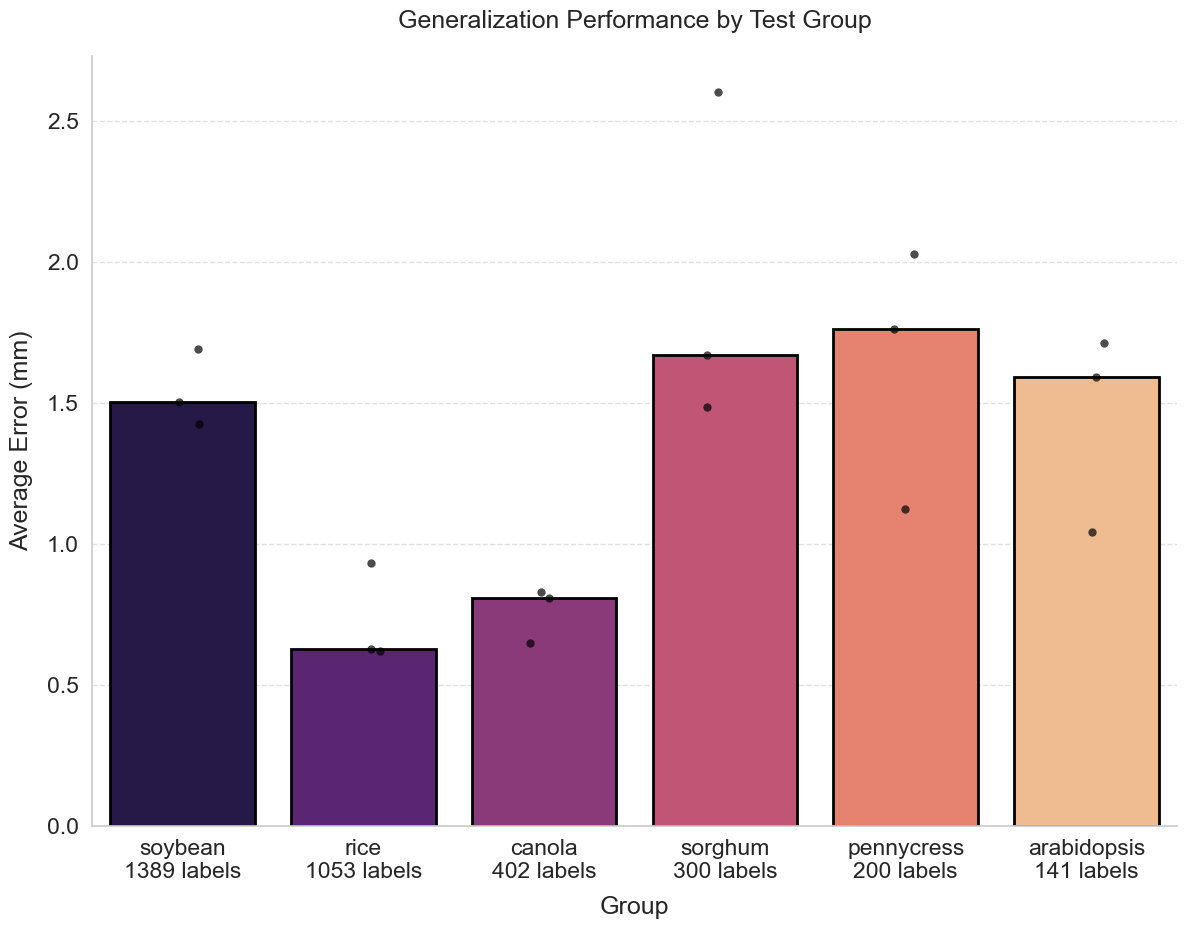

Plot saved to 2025-04-16_generalizable_model_aug_input_scale\2025-04-18_08-53-20_generalizable_model_evaluation.png


In [17]:
# ========== SETTINGS ==========
font_settings = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 26
}

# Map group names to crop label keys in the CSV
label_name_map = {
    "rice": "younger_rice",  # main group name → CSV column name
}

plt.rcParams.update(font_settings)
sns.set_theme(style="whitegrid", font_scale=1.5)

# ========== LOAD LABEL COUNTS ==========
label_csv_path = LABEL_COUNTS_CSV_PATH
df_labels = pd.read_csv(label_csv_path)

# Sum train + val + test labels per crop using version 0 since all versions have the same ratios of train/val/test
df_labels_v0 = df_labels[df_labels["version"] == 0]
crop_columns = ["sorghum", "soybean", "canola", "pennycress", "younger_rice", "arabidopsis"]
total_labeled_per_crop = df_labels_v0[crop_columns].sum().to_dict()

# ========== PROCESS MAIN DATA ==========
# Use only prefix of group name (e.g., 'soybean')
df["group_name"] = df["group"].str.split("_").str[-1]
df["label_count"] = df["group_name"].replace(label_name_map).map(total_labeled_per_crop)

# Reorder by total label count
sorted_groups = df.groupby("group_name")["label_count"].first().sort_values(ascending=False).index.tolist()
df["group_name"] = pd.Categorical(df["group_name"], categories=sorted_groups, ordered=True)

# ========== PLOTTING ==========
plt.figure(figsize=(14, 10))

# Barplot (median dist_avg)
ax = sns.barplot(
    data=df, x="group_name", y="dist_avg",
    estimator=np.median, ci=None,
    palette="magma", edgecolor="black", linewidth=2
)

# Overlay raw points
sns.stripplot(
    data=df, x="group_name", y="dist_avg",
    color="black", size=6, alpha=0.7, jitter=True
)

# Annotate bars with total labeled frame count
group_label_counts = df.groupby("group_name")["label_count"].first().to_dict()
for i, bar in enumerate(ax.patches):
    group = sorted_groups[i]
    label_count = group_label_counts.get(group, "N/A")
    height = bar.get_height()
    # ax.text(
    #     bar.get_x() + bar.get_width() / 2, height + 0.2,
    #     f"{label_count} total labels", ha="center", va="bottom",
    #     fontsize=12, color="black"
    # )

# Title and axis labels
# Create multi-line xtick labels: "group\n1234 labels"
xtick_labels = [
    f"{group}\n{group_label_counts.get(group, 'N/A')} labels" for group in sorted_groups
]
ax.set_xticklabels(xtick_labels, rotation=0, ha="center")
plt.title("Generalization Performance by Test Group", pad=20)
plt.xlabel("Group", labelpad=10)
plt.ylabel("Average Error (mm)", labelpad=10)

# Readability adjustments
# plt.xticks(rotation=45, ha="right")
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.6)


# Save
plot_file_path = Path(EXPERIMENT_NAME) / f"{datetime_str}_generalizable_model_evaluation.png"
plt.savefig(plot_file_path, dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print(f"Plot saved to {plot_file_path}")


Combined metrics saved to 2025-04-16_generalizable_model_aug_input_scale\2025-04-18_08-53-20_self_vs_generalist_comparison.csv


C:\Users\pbiobgh\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:66: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

c:\Users\pbiobgh\.conda\envs\sleap_v1.3.4\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


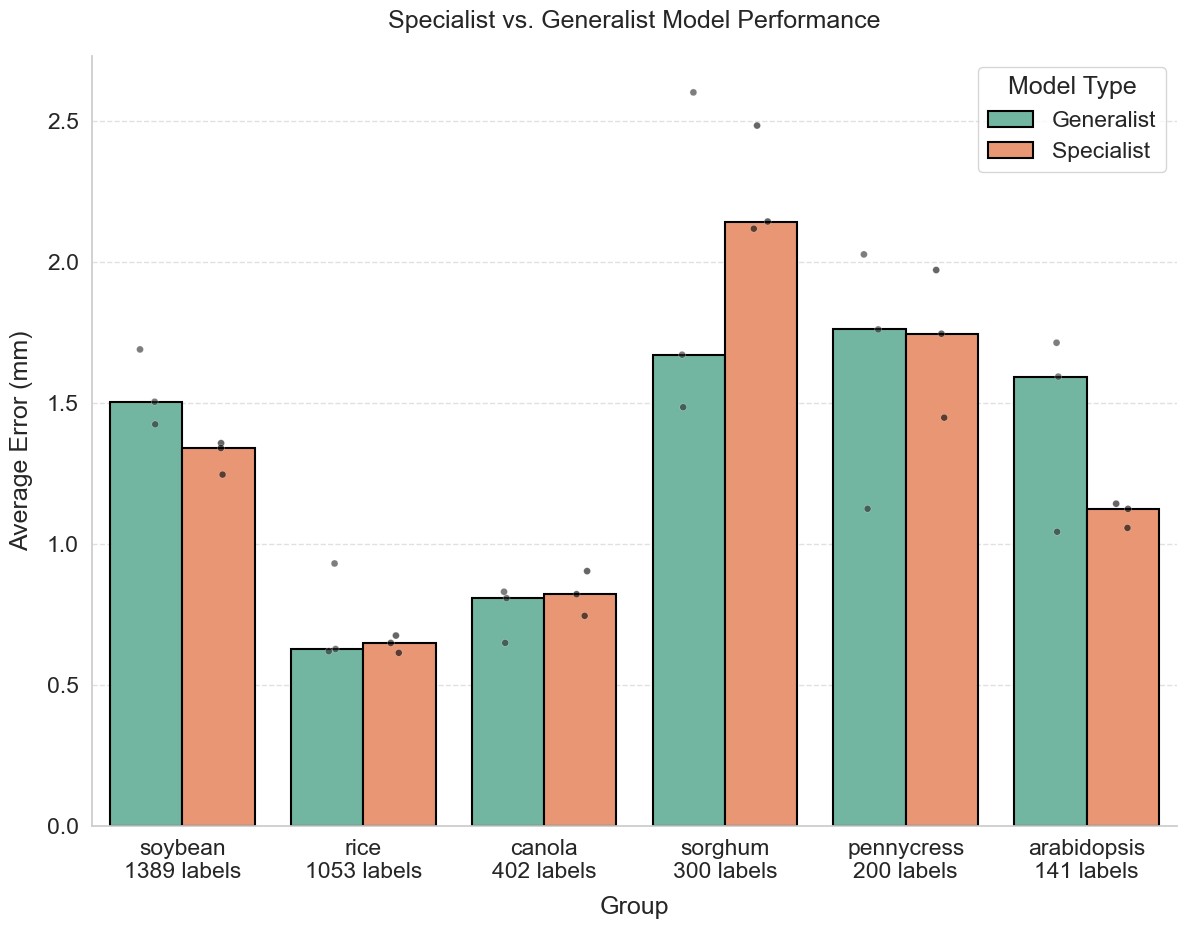

Comparison plot saved to 2025-04-16_generalizable_model_aug_input_scale\2025-04-18_08-53-20_self_vs_generalist_comparison.png


In [19]:
# ========== SETTINGS ==========
font_settings = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 26
}

label_name_map = {
    "rice": "younger_rice",
}

plt.rcParams.update(font_settings)
sns.set_theme(style="whitegrid", font_scale=1.5)

# ========== LABEL COUNTS ==========
label_csv_path = LABEL_COUNTS_CSV_PATH
df_labels = pd.read_csv(label_csv_path)
df_labels_v0 = df_labels[df_labels["version"] == 0]
crop_columns = ["sorghum", "soybean", "canola", "pennycress", "younger_rice", "arabidopsis"]
total_labeled_per_crop = df_labels_v0[crop_columns].sum().to_dict()

# ========== PREP GENERALIZABLE RESULTS ==========
df["group_name"] = df["group"].str.split("_").str[-1]
df["label_key"] = df["group_name"].replace(label_name_map)
df["label_count"] = df["label_key"].map(total_labeled_per_crop)

df_general = df[["group_name", "version", "dist_avg", "label_count"]].copy()
df_general["model_type"] = "Generalist"

# ========== LOAD SELF-EVALUATION RESULTS ==========
self_df = self_metrics_df.copy()
self_df["group_name"] = self_df["group"].str.split("_").str[-1]
self_df["label_key"] = self_df["group_name"].replace(label_name_map)
self_df["label_count"] = self_df["label_key"].map(total_labeled_per_crop)
self_df["model_type"] = "Specialist"
self_df = self_df.rename(columns={"dist_avg": "error_mm"})

# Match format to generalizable df
df_general = df_general.rename(columns={"dist_avg": "error_mm"})
df_general = df_general[["group_name", "version", "error_mm", "label_count", "model_type"]]
self_df = self_df[["group_name", "version", "error_mm", "label_count", "model_type"]]

# ========== COMBINE AND ORDER ==========
df_combined = pd.concat([df_general, self_df], axis=0)
sorted_groups = df_combined.groupby("group_name")["label_count"].first().sort_values(ascending=False).index.tolist()
df_combined["group_name"] = pd.Categorical(df_combined["group_name"], categories=sorted_groups, ordered=True)
df_combined.to_csv(Path(EXPERIMENT_NAME) / f"{datetime_str}_self_vs_generalist_comparison.csv", index=False)
print(f"Combined metrics saved to {Path(EXPERIMENT_NAME) / f'{datetime_str}_self_vs_generalist_comparison.csv'}")

# ========== PLOTTING ==========

plt.figure(figsize=(14, 10))

# Barplot with median estimator
ax = sns.barplot(
    data=df_combined,
    x="group_name", y="error_mm",
    hue="model_type", ci=None,
    estimator=np.median,
    palette="Set2", edgecolor="black", linewidth=1.5
)

# Overlay jittered data points
sns.stripplot(
    data=df_combined,
    x="group_name", y="error_mm",
    hue="model_type", dodge=True,
    jitter=True, color="black", size=5, alpha=0.6,
    marker="o", linewidth=0.3, edgecolor="white"
)

# Fix duplicate legend from stripplot
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[2:], labels[2:], title="Model Type", loc="upper right")

# Add custom x-tick labels: "group\n1234 labels"
group_label_counts = df_combined.groupby("group_name")["label_count"].first().to_dict()
xtick_labels = [f"{group}\n{group_label_counts.get(group, 'N/A')} labels" for group in sorted_groups]
ax.set_xticklabels(xtick_labels, rotation=0, ha="center")

# Titles and axes
plt.title("Specialist vs. Generalist Model Performance", pad=20)
plt.xlabel("Group", labelpad=10)
plt.ylabel("Average Error (mm)", labelpad=10)

# Grid and style
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Save
plot_file_path = Path(EXPERIMENT_NAME) / f"{datetime_str}_self_vs_generalist_comparison.png"
plt.savefig(plot_file_path, dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print(f"Comparison plot saved to {plot_file_path}")


Saved SLEAP grid visualization to 2025-04-16_generalizable_model_aug_input_scale\2025-04-18_08-53-20_predictions_grid_frame6.png


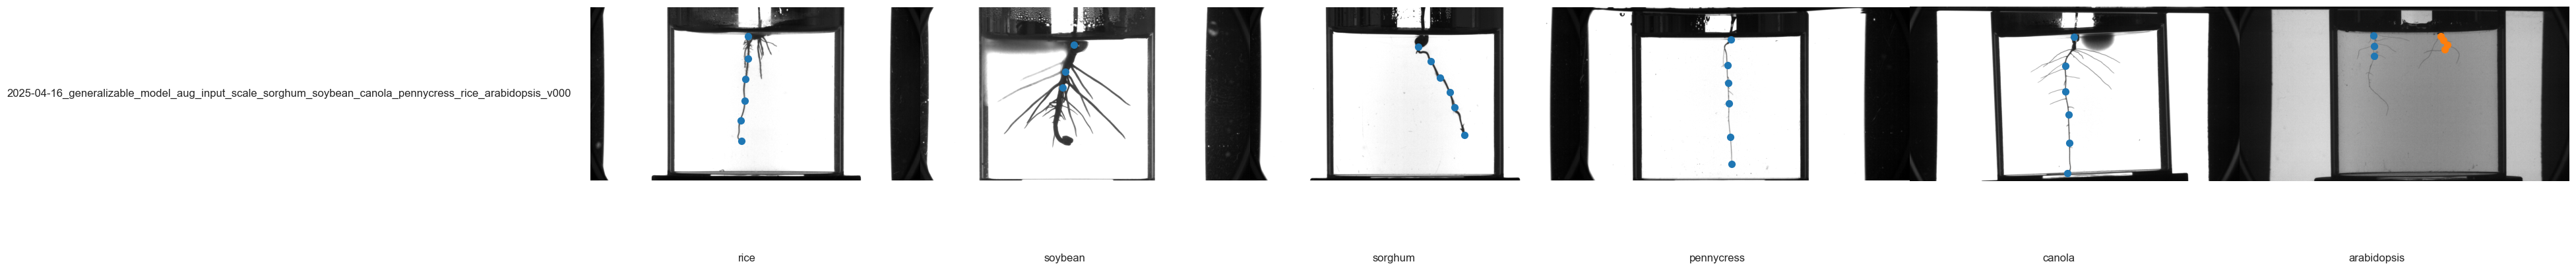

In [21]:
selected_version = "000"
model_name = f"{MODEL_GROUP}_v{selected_version}"
frame_index = 6

# Paths and settings
prediction_files = []
test_group_names = []

for group in GROUPS:
    test_set = f"{group}_v{selected_version}"
    run_dir = Path(EXPERIMENT_NAME) / f"{model_name}_on_{test_set}_{datetime_str}"
    prediction_path = run_dir / f"{model_name}_on_{test_set}_test_predictions.slp"

    if prediction_path.exists():
        prediction_files.append(prediction_path.as_posix())
        # Clean group name (remove suffix)
        test_group_names.append(group.split("_")[-1])
    else:
        print(f"Missing prediction file: {prediction_path}")

# Call the grid visualization function
predictions_viz_from_sleap_files(
    prediction_files_grid=[prediction_files],  # wrap in another list: 1 row
    test_group_names=test_group_names, # column label
    model_names=[model_name],  # row label
    output_path=Path(EXPERIMENT_NAME) / f"{datetime_str}_predictions_grid_frame{frame_index}.png",
    frame_idx=frame_index,
    figsize_scale=5,
    dpi=300,
    transparent=False,
    font_settings=font_settings,
    colormap="magma",
    spacing={
        "left": 0.00,
        "right": 1.00,
        "top": 1.00,
        "bottom": 0.00,
        "wspace": 0.0,
        "hspace": 0.0,
        }
)


In [23]:
# === Initialize the W&B run ===
add_files_run = wandb.init(
    project=PROJECT_NAME,
    entity=ENTITY_NAME,
    job_type="add_files_to_artifact"
)

# === Use existing artifact and download its contents ===
metrics_artifact = add_files_run.use_artifact(f"{ARTIFACT_NAME}:latest", type="metrics")
artifact_dir = Path(metrics_artifact.download())
print(f"Artifact downloaded to: {artifact_dir}")

# === Create a new artifact ===
new_metrics_artifact = wandb.Artifact(name=ARTIFACT_NAME, type="metrics")

# === Add generalizable model plots ===
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_self_vs_generalist_comparison.png").as_posix())
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_generalizable_model_evaluation.png").as_posix())
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_predictions_grid_frame{frame_index}.png").as_posix())

# === Add associated CSVs ===
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_generalizable_model_evaluation_metrics.csv").as_posix())
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_self_vs_generalist_comparison.csv").as_posix())
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_self_model_evaluation_metrics.csv").as_posix())
new_metrics_artifact.add_file(label_csv_path)

# === Add existing artifact contents ===
for file_path in artifact_dir.iterdir():
    new_metrics_artifact.add_file(file_path)

# === Log and finish ===
add_files_run.log_artifact(new_metrics_artifact)
add_files_run.finish()

wandb:   1 of 1 files downloaded.  


Artifact downloaded to: e:\repositories\sleap-roots-training\artifacts\primary-root-model-metrics-v6
